# Equity Data — Explanation Notebook

This notebook demonstrates the equity data layer that feeds the portfolio
risk engine. It loads daily closing prices for three equities, derives
returns and summary statistics, and inspects the diversification structure
of the basket.

The three tickers — AAPL, MSFT, XOM — were chosen to produce a non-trivial
correlation structure: two tech names with moderate cross-correlation and
an energy name that is largely uncorrelated with either. This makes the
diversification benefit in portfolio VaR observable rather than incidental.

What to look for:
- A populated price panel covering 5 years of trading days
- Annualised volatilities in a sensible range (~20–35%)
- A correlation matrix where tech-tech > tech-energy
- Return distributions that are approximately normal but with visible fat tails


In [1]:
# Setup
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.equity_data import (
    load_equity_panel,
    compute_log_returns,
    summary_table,
    correlation_matrix,
)

TICKERS = ["AAPL", "MSFT", "XOM"]
START_DATE = "2021-05-19"
END_DATE = "2026-05-19"


## 1. Equity spot and history

We load 5 years of daily closing prices for the three tickers. The loader
checks a local CSV cache first (`data/equities/<TICKER>.csv`) and falls
back to Yahoo Finance only on cache miss. This makes the notebook fully
reproducible offline once the cache is populated, and avoids hitting
yfinance's rate limit on repeated runs.


In [2]:
# Load price panel for all three tickers (reads from local cache -> offline run)
# cache_dir is resolved relative to the repo root, since the notebook runs from notebooks/
CACHE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "equities"))

panel = load_equity_panel(TICKERS, START_DATE, END_DATE, cache_dir=CACHE_DIR)
panel.tail()


Loaded 1255 daily observations for AAPL from cache (/Users/cathylin/Desktop/Derivative_Platform/data/equities/AAPL.csv)
  Date range: 2021-05-19 to 2026-05-18
  Latest close: 297.84
Loaded 1255 daily observations for MSFT from cache (/Users/cathylin/Desktop/Derivative_Platform/data/equities/MSFT.csv)
  Date range: 2021-05-19 to 2026-05-18
  Latest close: 423.54
Loaded 1255 daily observations for XOM from cache (/Users/cathylin/Desktop/Derivative_Platform/data/equities/XOM.csv)
  Date range: 2021-05-19 to 2026-05-18
  Latest close: 160.49


,AAPL,MSFT,XOM
Date,,,
2026-05-12,294.799988,407.769989,149.614502
2026-05-13,298.869995,405.209991,150.548172
2026-05-14,298.209991,409.429993,151.750000
2026-05-15,300.230011,421.920013,157.919998
2026-05-18,297.839996,423.540009,160.490005


## 2. Summary diagnostics

For each ticker we compute:
- **spot**: the latest closing price
- **ann_vol**: annualised volatility, estimated from daily log returns
  using $\sigma_\text{ann} = \sigma_\text{daily} \times \sqrt{252}$
- **n_obs**: number of return observations (one less than price obs)


In [3]:
returns = compute_log_returns(panel)
summary = summary_table(panel, returns)
summary.round(4)


,spot,ann_vol,n_obs
AAPL,297.84,0.2735,1254.0
MSFT,423.54,0.2638,1254.0
XOM,160.49,0.2669,1254.0


**Interpretation.** All three tickers have annualised volatilities clustered
in the 26–28% range over this 5-year window — a relatively stable regime.
XOM's vol is comparable to the tech names, reflecting calm energy markets
in the recent sample.


## 3. Price history

To compare relative performance, we normalise each price series to 100 at
the start of the window. This shows percentage growth from a common base,
removing the obvious scale differences (MSFT at $400+ vs XOM at $160).


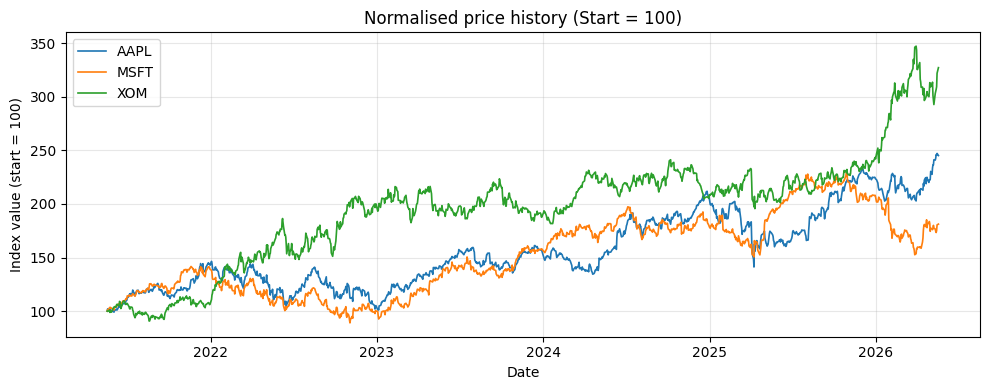

In [4]:
# Normalise each ticker to 100 at the start of the window
normalised = panel / panel.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 4))
for ticker in TICKERS:
    ax.plot(normalised.index, normalised[ticker], label=ticker, linewidth=1.2)

ax.set_title("Normalised price history (Start = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Index value (start = 100)")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Return distributions

We plot the daily log return distribution for each ticker. Parametric VaR
assumes returns are approximately normal — these histograms let us check
visually whether that assumption is defensible, and where it breaks down.


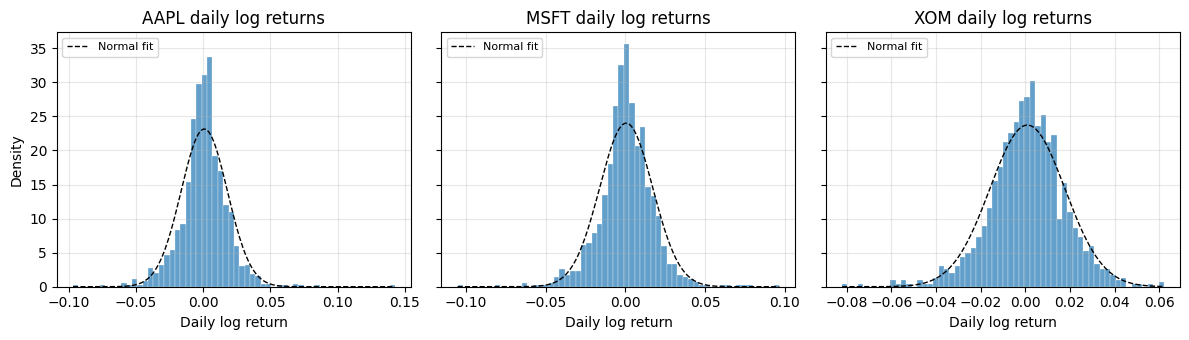

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)

for ax, ticker in zip(axes, TICKERS):
    r = returns[ticker]
    ax.hist(r, bins=60, density=True, alpha=0.7, edgecolor="white", linewidth=0.3)
    # Overlay a normal density for visual comparison
    x = np.linspace(r.min(), r.max(), 200)
    pdf = (1 / (r.std() * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - r.mean()) / r.std()) ** 2)
    ax.plot(x, pdf, "k--", linewidth=1, label="Normal fit")
    ax.set_title(f"{ticker} daily log returns")
    ax.set_xlabel("Daily log return")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.show()


**Interpretation.** The empirical distributions are roughly bell-shaped and
centred near zero, consistent with the normal assumption underlying
parametric VaR. However, all three show **fat tails** — extreme returns
(both positive and negative) occur more often than a normal distribution
would predict. This is a well-known limitation of the parametric approach
and motivates using historical VaR alongside it for comparison.


## 5. Correlation matrix

The pairwise correlation of daily log returns drives portfolio diversification.
A diagonal of 1s and meaningful off-diagonal structure is what we want for
the portfolio risk story.


In [6]:
corr = correlation_matrix(returns)
corr.round(4)


,AAPL,MSFT,XOM
AAPL,1.0000,0.5816,0.1874
MSFT,0.5816,1.0000,0.0615
XOM,0.1874,0.0615,1.0000


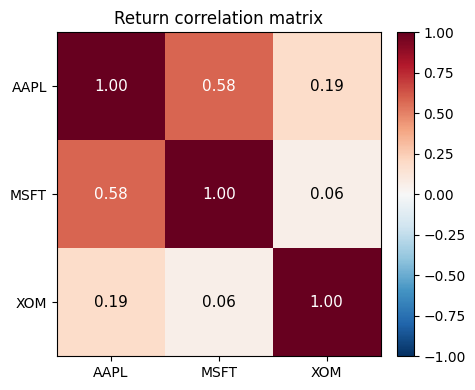

In [7]:
# Heatmap of the correlation matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS)
ax.set_yticklabels(TICKERS)

# Annotate each cell with the correlation value
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}",
                ha="center", va="center",
                color="white" if abs(corr.values[i, j]) > 0.5 else "black",
                fontsize=11)

ax.set_title("Return correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


**Interpretation.** The two tech names (AAPL and MSFT) correlate at roughly
0.58, reflecting shared sector and macro exposure. Both correlate weakly
with XOM — under 0.20 for AAPL-XOM and near zero for MSFT-XOM — because
energy and large-cap tech respond to different demand drivers.

This is precisely the kind of structure that lets a portfolio benefit from
diversification: combining the basket reduces aggregate variance relative
to holding any single name at the same total exposure. The portfolio risk
layer (next workstream) quantifies this benefit explicitly through
parametric VaR.
